### 1

In [20]:
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np


In [21]:
dataset_path = 'dataset/Base.csv'
data = pd.read_csv(dataset_path)

In [22]:
fraud = data[data['fraud_bool'] == 1]
legal = data[data['fraud_bool'] == 0]
legal_downsampled = resample(legal, replace=False, n_samples=len(fraud), random_state=42)
balanced_data = pd.concat([fraud, legal_downsampled])

In [23]:
le = LabelEncoder()
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
for col in cat_cols:
    balanced_data[col] = le.fit_transform(balanced_data[col])

In [24]:
X = balanced_data.drop('fraud_bool', axis=1)
y = balanced_data['fraud_bool']

In [25]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

In [26]:
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_final = scaler.fit_transform(X_pca)
 
print(f"Forma finale del dataset: {X_final.shape}")

Forma finale del dataset: (22058, 4)


### 2

/tmp/ipykernel_11140/60130012.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='linear')


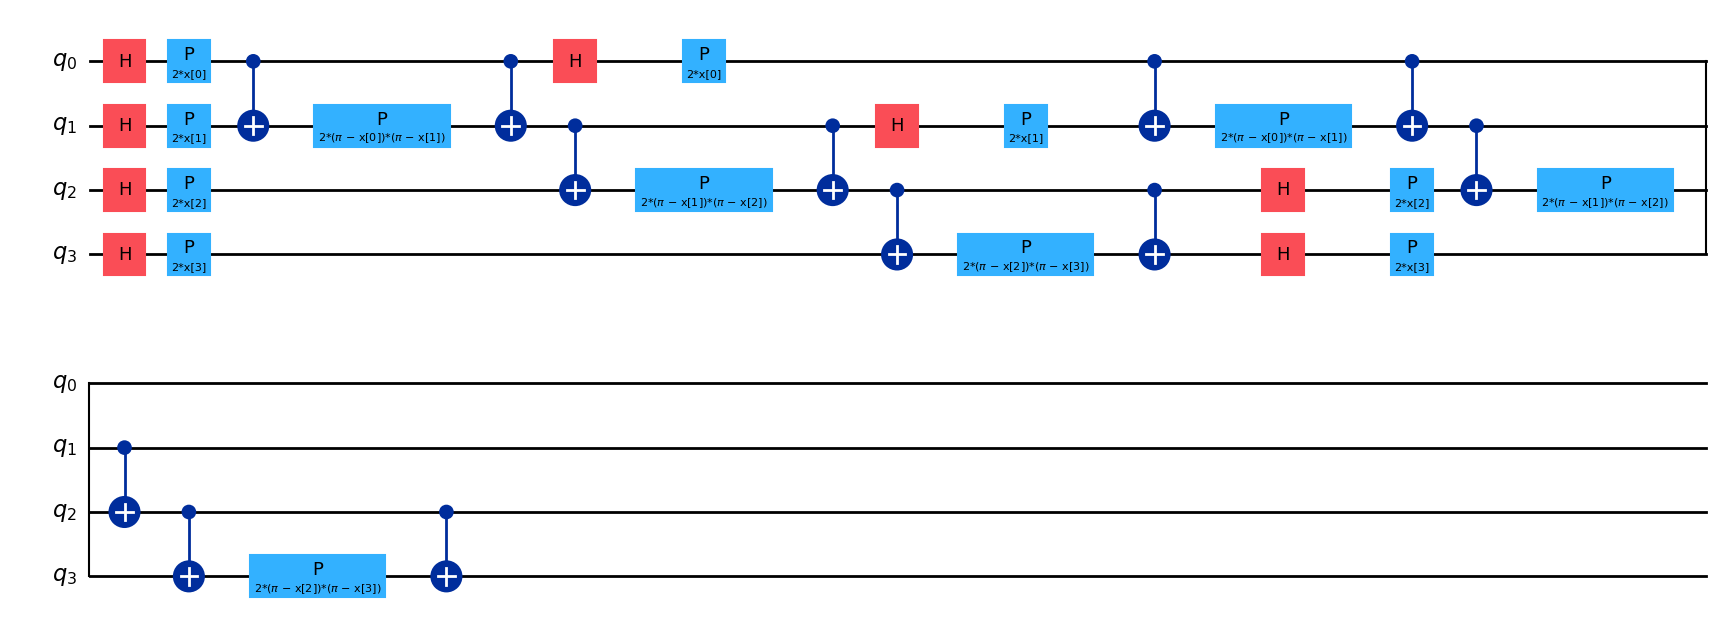

In [27]:
from qiskit.circuit.library import ZZFeatureMap

num_qubits = 4
# reps = 2 indica quante volte ripetere il pattern di encoding (maggiore profondità = più complessità catturata)
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=2, entanglement='linear')

# Visualizziamo il circuito per capire come vengono mappati i dati
feature_map.decompose().draw(output='mpl')

### 3

In [10]:
from sklearn.model_selection import train_test_split
 
# Dividiamo il dataset (es. 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Campioni di training: {len(X_train)}")
print(f"Campioni di test: {len(X_test)}")

Campioni di training: 17646
Campioni di test: 4412


C:\Users\matti\AppData\Local\Temp\ipykernel_14492\349544662.py:4: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=num_qubits, reps=3, entanglement='linear')


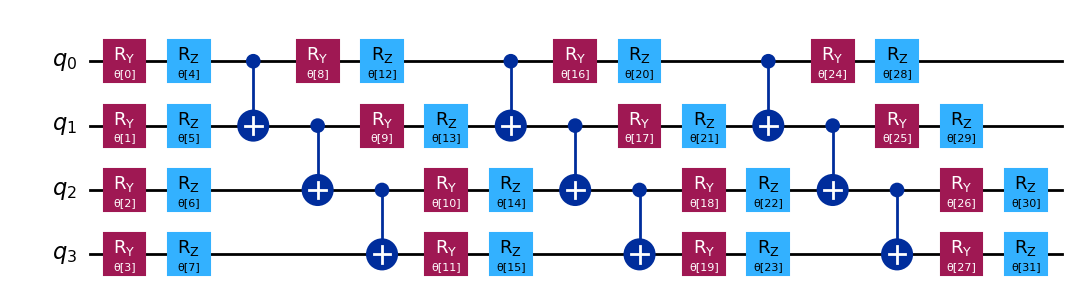

In [11]:
#Crea l'ansatz 
from qiskit.circuit.library import EfficientSU2
 
ansatz = EfficientSU2(num_qubits=num_qubits, reps=3, entanglement='linear')
ansatz.decompose().draw(output='mpl')

In [16]:
#Setup del VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms import VQC
from qiskit_aer.primitives import Sampler
 
# Definiamo l'ottimizzatore (COBYLA è ottimo per simulazioni senza rumore)
optimizer = COBYLA(maxiter=100)
 
# Setup del classificatore
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    sampler=Sampler(),
    # La funzione di callback ci permetterà di vedere l'andamento del training (settimana 4)
)
 
print("VQC inizializzato e pronto per il training!")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


VQC inizializzato e pronto per il training!


### 4

In [ ]:
import time
from IPython.display import clear_output

objective_func_vals = []

def callback_graph(weights, obj_val):
    clear_output(wait=True)
    objective_func_vals.append(obj_val)
    plt.title("Andamento del Training (Loss Function)")
    plt.xlabel("Iterazione")
    plt.ylabel("Loss")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

# Aggiorniamo il VQC con la callback
vqc.callback = callback_graph


In [ ]:
# Se vuoi fare un test veloce, scommenta la riga sotto:
# X_train_small, y_train_small = X_train[:100], y_train[:100]

start_time = time.time()
vqc.fit(X_train, y_train.values) # .values per passare un array numpy
end_time = time.time()

print(f"Training completato in {end_time - start_time:.2f} secondi")


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predizione sul test set
y_pred = vqc.predict(X_test)

# Report completo (Precision, Recall, F1)
print("\n--- Risultati del Modello ---")
print(classification_report(y_test, y_pred, target_names=['Legale', 'Frode']))

# Visualizzazione Matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legale', 'Frode'])
disp.plot(cmap='Blues')
plt.title("Matrice di Confusione")
plt.show()
